In [1]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
#from sklearn.model_selection

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/online_retail_listing.csv",encoding="unicode_escape",delimiter=";")

In [3]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,"1,25",13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,4.12.2011 13:00,"8,25",14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,4.12.2011 13:00,"4,95",14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,4.12.2011 13:15,"1,65",16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,4.12.2011 13:15,"2,89",16931.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  object 
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 64.0+ MB


In [5]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,4372
Quantity,0
InvoiceDate,0
Price,0
Customer ID,236682
Country,0


In [6]:
df.dropna(inplace=True)

In [7]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [8]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [9]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,object
Customer ID,float64
Country,object


In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,"1,25",13085.0,United Kingdom


In [11]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"],errors='coerce')

df["Price"] = df["Price"].replace("," , "", regex=True)
df["Price"] = pd.to_numeric(df["Price"])

In [12]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,int64
Customer ID,float64
Country,object


In [13]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-01-12 07:45:00,695,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-01-12 07:45:00,675,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-01-12 07:45:00,675,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-01-12 07:45:00,21,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-01-12 07:45:00,125,13085.0,United Kingdom


## **Now Let's Calculate RFM**

In [14]:
#Calculate Recency
df_Recency = df.groupby(by="Customer ID",as_index=False)["InvoiceDate"].max()  #last date of a customer,who purchased with us
                                                                               #(as_index=False) means it will not take "Customer ID" as index column

In [15]:
df_Recency

,Customer ID,InvoiceDate
0,12346.0,2010-04-10 16:33:00
1,12347.0,2011-09-06 13:01:00
2,12348.0,2011-05-04 10:47:00
3,12349.0,2009-04-12 12:49:00
4,12350.0,2011-02-02 16:01:00
...,...,...
5919,18283.0,2011-10-11 15:07:00
5920,18284.0,2010-06-10 12:31:00
5921,18285.0,NaT
5922,18286.0,NaT


In [16]:
Recent_data = df_Recency["InvoiceDate"].max()
Recent_data

Timestamp('2011-12-10 17:19:00')

In [17]:
#calculating the Difference and save it in New column called Recency
df_Recency["Recency"] = df_Recency["InvoiceDate"].apply(lambda x:(Recent_data - x).days)  # x-whatever the data value in that column
df_Recency                                                                                #(.days)-it only take days and ignore time

,Customer ID,InvoiceDate,Recency
0,12346.0,2010-04-10 16:33:00,609.0
1,12347.0,2011-09-06 13:01:00,95.0
2,12348.0,2011-05-04 10:47:00,220.0
3,12349.0,2009-04-12 12:49:00,972.0
4,12350.0,2011-02-02 16:01:00,311.0
...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0
5920,18284.0,2010-06-10 12:31:00,548.0
5921,18285.0,NaT,NaN
5922,18286.0,NaT,NaN


In [18]:
#Calculate Frequency
df_Frequency = df.drop_duplicates().groupby(by="Customer ID",as_index=False)["InvoiceDate"].count()
df_Frequency.columns= ["Customer ID","Frequency"]
df_Frequency

,Customer ID,Frequency
0,12346.0,9
1,12347.0,95
2,12348.0,5
3,12349.0,5
4,12350.0,17
...,...,...
5919,18283.0,185
5920,18284.0,29
5921,18285.0,0
5922,18286.0,0


In [19]:
#Calculate Monetary Value

In [20]:
#Each customer purchase no.of times
df["Total Price"] = df["Quantity"]*df["Price"]
df["Total Price"]
#we get total price of a customer in that single(particular) purchase

,Total Price
0,8340
1,8100
2,8100
3,1008
4,3000
...,...
1048570,1650
1048571,1485
1048572,495
1048573,578


In [21]:
df_Monetary = df.groupby(by="Customer ID",as_index=False)["Total Price"].sum()   #this will add all the purchased amount of a each customer
df_Monetary.columns= ["Customer ID","Monetary"]
df_Monetary

,Customer ID,Monetary
0,12346.0,-14973
1,12347.0,529672
2,12348.0,166201
3,12349.0,350634
4,12350.0,20408
...,...,...
5919,18283.0,240157
5920,18284.0,38925
5921,18285.0,34690
5922,18286.0,109735


In [22]:
#RFM Score  #Merge all tha Three
RFM_df = df_Recency.merge(df_Frequency,on="Customer ID").merge(df_Monetary,on="Customer ID")
RFM_df

,Customer ID,InvoiceDate,Recency,Frequency,Monetary
0,12346.0,2010-04-10 16:33:00,609.0,9,-14973
1,12347.0,2011-09-06 13:01:00,95.0,95,529672
2,12348.0,2011-05-04 10:47:00,220.0,5,166201
3,12349.0,2009-04-12 12:49:00,972.0,5,350634
4,12350.0,2011-02-02 16:01:00,311.0,17,20408
...,...,...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0,185,240157
5920,18284.0,2010-06-10 12:31:00,548.0,29,38925
5921,18285.0,NaT,NaN,0,34690
5922,18286.0,NaT,NaN,0,109735


In [23]:
RFM_df["Rank_recency"] = RFM_df["Recency"].rank(ascending=False) #Customer who purchased yesterday is better than Customer who purchased 5days before(eg:5days)

In [24]:
RFM_df["Rank_freq"] = RFM_df["Frequency"].rank(ascending=True) #Person who has more is better

In [25]:
RFM_df["Rank_monetary"] = RFM_df["Recency"].rank(ascending=True)   #Person who has more monetary value is better for us

In [26]:
RFM_df

,Customer ID,InvoiceDate,Recency,Frequency,Monetary,Rank_recency,Rank_freq,Rank_monetary
0,12346.0,2010-04-10 16:33:00,609.0,9,-14973,422.5,2293.0,3955.5
1,12347.0,2011-09-06 13:01:00,95.0,95,529672,2986.0,5062.5,1392.0
2,12348.0,2011-05-04 10:47:00,220.0,5,166201,2093.0,1992.0,2285.0
3,12349.0,2009-04-12 12:49:00,972.0,5,350634,48.5,1992.0,4329.5
4,12350.0,2011-02-02 16:01:00,311.0,17,20408,1695.0,2880.0,2683.0
...,...,...,...,...,...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0,185,240157,3444.0,5541.5,934.0
5920,18284.0,2010-06-10 12:31:00,548.0,29,38925,629.5,3590.0,3748.5
5921,18285.0,NaT,NaN,0,34690,NaN,774.0,NaN
5922,18286.0,NaT,NaN,0,109735,NaN,774.0,NaN


In [27]:
RFM_df["Rank_recency_Normalised"] = RFM_df["Rank_recency"]/RFM_df["Rank_recency"].max()*100

In [28]:
RFM_df["Rank_freq_Normalised"] = RFM_df["Rank_freq"]/RFM_df["Rank_freq"].max()*100

In [29]:
RFM_df["Rank_monetary_Normalised"] = RFM_df["Rank_monetary"]/RFM_df["Rank_monetary"].max()*100

In [30]:
RFM_df

,Customer ID,InvoiceDate,Recency,Frequency,Monetary,Rank_recency,Rank_freq,Rank_monetary,Rank_recency_Normalised,Rank_freq_Normalised,Rank_monetary_Normalised
0,12346.0,2010-04-10 16:33:00,609.0,9,-14973,422.5,2293.0,3955.5,9.754127,38.706955,90.473468
1,12347.0,2011-09-06 13:01:00,95.0,95,529672,2986.0,5062.5,1392.0,68.936858,85.457461,31.838975
2,12348.0,2011-05-04 10:47:00,220.0,5,166201,2093.0,1992.0,2285.0,48.320443,33.625928,52.264410
3,12349.0,2009-04-12 12:49:00,972.0,5,350634,48.5,1992.0,4329.5,1.119704,33.625928,99.027905
4,12350.0,2011-02-02 16:01:00,311.0,17,20408,1695.0,2880.0,2683.0,39.131940,48.615800,61.367795
...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0,185,240157,3444.0,5541.5,934.0,79.510562,93.543214,21.363220
5920,18284.0,2010-06-10 12:31:00,548.0,29,38925,629.5,3590.0,3748.5,14.533072,60.600945,85.738792
5921,18285.0,NaT,NaN,0,34690,NaN,774.0,NaN,NaN,13.065496,NaN
5922,18286.0,NaT,NaN,0,109735,NaN,774.0,NaN,NaN,13.065496,NaN


In [31]:
RFM_df["RFM_Score"] = 0.15*RFM_df["Rank_recency_Normalised"] + 0.28*RFM_df["Rank_freq_Normalised"] + 0.57*RFM_df["Rank_monetary_Normalised"]
RFM_df["RFM_Score"] *=0.05
RFM_df= RFM_df.round(2)
RFM_df

,Customer ID,InvoiceDate,Recency,Frequency,Monetary,Rank_recency,Rank_freq,Rank_monetary,Rank_recency_Normalised,Rank_freq_Normalised,Rank_monetary_Normalised,RFM_Score
0,12346.0,2010-04-10 16:33:00,609.0,9,-14973,422.5,2293.0,3955.5,9.75,38.71,90.47,3.19
1,12347.0,2011-09-06 13:01:00,95.0,95,529672,2986.0,5062.5,1392.0,68.94,85.46,31.84,2.62
2,12348.0,2011-05-04 10:47:00,220.0,5,166201,2093.0,1992.0,2285.0,48.32,33.63,52.26,2.32
3,12349.0,2009-04-12 12:49:00,972.0,5,350634,48.5,1992.0,4329.5,1.12,33.63,99.03,3.30
4,12350.0,2011-02-02 16:01:00,311.0,17,20408,1695.0,2880.0,2683.0,39.13,48.62,61.37,2.72
...,...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0,185,240157,3444.0,5541.5,934.0,79.51,93.54,21.36,2.51
5920,18284.0,2010-06-10 12:31:00,548.0,29,38925,629.5,3590.0,3748.5,14.53,60.60,85.74,3.40
5921,18285.0,NaT,NaN,0,34690,NaN,774.0,NaN,NaN,13.07,NaN,NaN
5922,18286.0,NaT,NaN,0,109735,NaN,774.0,NaN,NaN,13.07,NaN,NaN


In [32]:
RFM_df[["Customer ID","RFM_Score"]]

,Customer ID,RFM_Score
0,12346.0,3.19
1,12347.0,2.62
2,12348.0,2.32
3,12349.0,3.30
4,12350.0,2.72
...,...,...
5919,18283.0,2.51
5920,18284.0,3.40
5921,18285.0,NaN
5922,18286.0,NaN


# Rating Customer Based on the RFM Score

- rfm score > 4.5 : Top Customer
- 4.5 > rfm score > 4 : High Value Customer
- 4 > rfm score > 3 : Mid Value Customer
- 3 > rfm score > 1.6 : Low Value Customer
- rfm score < 1.6 : Lost

In [36]:
RFM_df['Customer Segment']=np.where(RFM_df['RFM_Score'] > 4.5,"Top Customer",
                                    (np.where(RFM_df['RFM_Score'] > 4,"High value Customer",
                                    (np.where(RFM_df['RFM_Score'] > 3, "Mid Value Customer",
                                    np.where(RFM_df['RFM_Score'] > 1.6 , " Low value Customer", "Lost Customer"))))))


In [37]:
RFM_df

,Customer ID,InvoiceDate,Recency,Frequency,Monetary,Rank_recency,Rank_freq,Rank_monetary,Rank_recency_Normalised,Rank_freq_Normalised,Rank_monetary_Normalised,RFM_Score,Customer Segment
0,12346.0,2010-04-10 16:33:00,609.0,9,-14973,422.5,2293.0,3955.5,9.75,38.71,90.47,3.19,Mid Value Customer
1,12347.0,2011-09-06 13:01:00,95.0,95,529672,2986.0,5062.5,1392.0,68.94,85.46,31.84,2.62,Low value Customer
2,12348.0,2011-05-04 10:47:00,220.0,5,166201,2093.0,1992.0,2285.0,48.32,33.63,52.26,2.32,Low value Customer
3,12349.0,2009-04-12 12:49:00,972.0,5,350634,48.5,1992.0,4329.5,1.12,33.63,99.03,3.30,Mid Value Customer
4,12350.0,2011-02-02 16:01:00,311.0,17,20408,1695.0,2880.0,2683.0,39.13,48.62,61.37,2.72,Low value Customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5919,18283.0,2011-10-11 15:07:00,60.0,185,240157,3444.0,5541.5,934.0,79.51,93.54,21.36,2.51,Low value Customer
5920,18284.0,2010-06-10 12:31:00,548.0,29,38925,629.5,3590.0,3748.5,14.53,60.60,85.74,3.40,Mid Value Customer
5921,18285.0,NaT,NaN,0,34690,NaN,774.0,NaN,NaN,13.07,NaN,NaN,Lost Customer
5922,18286.0,NaT,NaN,0,109735,NaN,774.0,NaN,NaN,13.07,NaN,NaN,Lost Customer


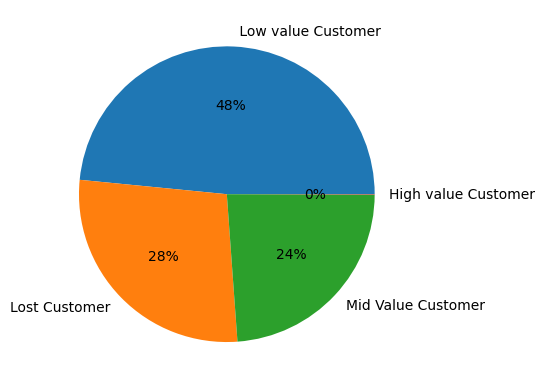

In [38]:
from matplotlib import pyplot as plt
plt.pie(RFM_df['Customer Segment'].value_counts(), labels=RFM_df['Customer Segment'].value_counts().index, autopct='%.0f%%')
plt.show()